# Advanced-2. Comparing Transpilation on Custom Targets

This chapter focuses on one specific transpilation question:

1. build a small **abstract circuit**,  
2. define custom backend-like **Targets**,  
3. transpile the same circuit against those targets,  
4. inspect what changes in the resulting ISA circuit,  
5. and then connect the target metadata to a **noisy simulation** of a mirrored circuit $U\;\texttt{barrier}\;U^\dagger$.

A `Target` is useful when we want to study how transpilation depends on hardware assumptions
without needing access to a real backend. At the same time, it is important to distinguish
between two layers:

- the **Target**, which guides compilation and records hardware-like properties,
- and the **noise model**, which is what a simulator actually uses to inject noise during execution.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.transpiler import Target, InstructionProperties
from qiskit.circuit.library import RZGate, SXGate, XGate, Measure, ECRGate


## A2-1. Define a Small Abstract Circuit

We first build a simple 4-qubit ansatz-like circuit.
At this stage the circuit is still **abstract**:
it is written in terms of convenient logical gates, not yet restricted to any backend ISA.

We will later transpile the same circuit onto different custom targets and compare the outcome.


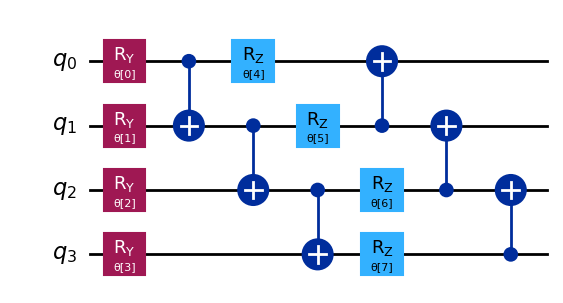

In [3]:
theta = ParameterVector("θ", 8)

ansatz = QuantumCircuit(4)
ansatz.ry(theta[0], 0)
ansatz.ry(theta[1], 1)
ansatz.ry(theta[2], 2)
ansatz.ry(theta[3], 3)
ansatz.cx(0, 1)
ansatz.cx(1, 2)
ansatz.cx(2, 3)
ansatz.rz(theta[4], 0)
ansatz.rz(theta[5], 1)
ansatz.rz(theta[6], 2)
ansatz.rz(theta[7], 3)
ansatz.cx(1, 0)
ansatz.cx(2, 1)
ansatz.cx(3, 2)

ansatz.draw("mpl", idle_wires=False)


## A2-2. Define Two Custom Targets

A `Target` specifies which instructions are supported on which qubits, together with
optional metadata such as durations and error rates.

Here we define two linear-chain custom targets with the same gate set and connectivity,
but with different error assumptions:

- a **lower-noise** target,
- and a **higher-noise** target.

This lets us separate:

- **ISA validity** and decomposition, from
- **performance expectations** under different hardware models.


In [4]:
def make_custom_target(
    n_qubits=4,
    ecr_error=0.01,
    sx_error=2e-4,
    x_error=2e-4,
    meas_error=0.02,
    ecr_duration=5.0e-7,
    sx_duration=3.5e-8,
    x_duration=3.5e-8,
    meas_duration=1.2e-6,
):
    theta_target = ParameterVector("θ_target", 1)[0]
    target = Target(num_qubits=n_qubits)

    target.add_instruction(
        RZGate(theta_target),
        {(q,): None for q in range(n_qubits)},
        name="rz",
    )
    target.add_instruction(
        SXGate(),
        {(q,): InstructionProperties(duration=sx_duration, error=sx_error) for q in range(n_qubits)},
        name="sx",
    )
    target.add_instruction(
        XGate(),
        {(q,): InstructionProperties(duration=x_duration, error=x_error) for q in range(n_qubits)},
        name="x",
    )
    target.add_instruction(
        Measure(),
        {(q,): InstructionProperties(duration=meas_duration, error=meas_error) for q in range(n_qubits)},
        name="measure",
    )
    target.add_instruction(
        ECRGate(),
        {
            (0, 1): InstructionProperties(duration=ecr_duration, error=ecr_error),
            (1, 2): InstructionProperties(duration=ecr_duration, error=ecr_error),
            (2, 3): InstructionProperties(duration=ecr_duration, error=ecr_error),
        },
        name="ecr",
    )
    return target

target_low_noise = make_custom_target(ecr_error=0.005, meas_error=0.01)
target_high_noise = make_custom_target(ecr_error=0.03, meas_error=0.05)


## A2-3. Transpile the Same Circuit onto Both Targets

Now we transpile the same abstract circuit against both targets.

Because the supported gate set and connectivity are the same, the transpiled circuits may end up
having the same structure. If that happens, it is still informative:
it means the `Target` metadata is changing the **hardware model** more than the **syntactic circuit form**.


In [5]:
isa_low = transpile(ansatz, target=target_low_noise, optimization_level=3, seed_transpiler=1234)
isa_high = transpile(ansatz, target=target_high_noise, optimization_level=3, seed_transpiler=1234)

summary = {
    "abstract_depth": ansatz.decompose().depth(),
    "isa_low_depth": isa_low.depth(),
    "isa_high_depth": isa_high.depth(),
    "isa_low_ops": dict(isa_low.count_ops()),
    "isa_high_ops": dict(isa_high.count_ops()),
}
summary


{'abstract_depth': 7,
 'isa_low_depth': 22,
 'isa_high_depth': 22,
 'isa_low_ops': {'rz': 30, 'sx': 14, 'x': 7, 'ecr': 6},
 'isa_high_ops': {'rz': 30, 'sx': 14, 'x': 7, 'ecr': 6}}

## A2-4. Inspect the Resulting ISA Circuit and Target Properties

We display one transpiled circuit and print the properties stored in the lower-noise target.

The important distinction is:

- the **transpiled circuit** tells us how the abstract program was rewritten into the target ISA,
- the **instruction properties** tell us how we should interpret that circuit on the assumed hardware.


In [6]:
isa_low.draw("mpl", idle_wires=False)

print("Low-noise custom target:")
for inst, qargs in target_low_noise.instructions:
    props = target_low_noise[inst.name].get(qargs, None)
    if props is not None and getattr(props, "error", None) is not None:
        print(f"{inst.name:8s} on {qargs}: error={props.error:.4g}, duration={props.duration}")


Low-noise custom target:
sx       on (0,): error=0.0002, duration=3.5e-08
sx       on (1,): error=0.0002, duration=3.5e-08
sx       on (2,): error=0.0002, duration=3.5e-08
sx       on (3,): error=0.0002, duration=3.5e-08
x        on (0,): error=0.0002, duration=3.5e-08
x        on (1,): error=0.0002, duration=3.5e-08
x        on (2,): error=0.0002, duration=3.5e-08
x        on (3,): error=0.0002, duration=3.5e-08
measure  on (0,): error=0.01, duration=1.2e-06
measure  on (1,): error=0.01, duration=1.2e-06
measure  on (2,): error=0.01, duration=1.2e-06
measure  on (3,): error=0.01, duration=1.2e-06
ecr      on (0, 1): error=0.005, duration=5e-07
ecr      on (1, 2): error=0.005, duration=5e-07
ecr      on (2, 3): error=0.005, duration=5e-07


## A2-5. Interpretation

In this small example, changing only the error metadata may or may not change the circuit structure.
That depends on which transpiler passes are active and whether they explicitly optimize against those properties.

So there are two separate lessons here:

1. a `Target` is first of all a way to specify a **valid ISA and connectivity model**,  
2. and only secondarily a source of **cost information** such as errors and durations.

For teaching, sensitivity analysis, or backend prototyping, custom targets are therefore a convenient way
to study how much of transpilation is driven by structural constraints and how much is driven by hardware metadata.
